<a href="https://colab.research.google.com/github/rocio-mr/rendimiento-academico/blob/main/Rendimiento_Acad%C3%A9mico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("rendimiento_estudiantil.csv")  #Importamos nuestra data desde un archivo csv
df.head(5)  #Mostramos los primeros 5 registros

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
#Vemos el tamaño entre filas y columnas que componen nuestro df
df.shape

(6607, 20)

In [3]:
#Averiguamos el tipo de dato de cada columna y si existen valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
#Obtenemos información  estadísticas acerca de cada columna numérica
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
#Seleccionamos las columnas con valores categóricas del df

df_categoricos = df.select_dtypes(include="object")

for col in df_categoricos.columns:
  print(f"\nColumna: {col}")
  print(df_categoricos[col].unique())



Columna: Parental_Involvement
['Low' 'Medium' 'High']

Columna: Access_to_Resources
['High' 'Medium' 'Low']

Columna: Extracurricular_Activities
['No' 'Yes']

Columna: Motivation_Level
['Low' 'Medium' 'High']

Columna: Internet_Access
['Yes' 'No']

Columna: Family_Income
['Low' 'Medium' 'High']

Columna: Teacher_Quality
['Medium' 'High' 'Low' nan]

Columna: School_Type
['Public' 'Private']

Columna: Peer_Influence
['Positive' 'Negative' 'Neutral']

Columna: Learning_Disabilities
['No' 'Yes']

Columna: Parental_Education_Level
['High School' 'College' 'Postgraduate' nan]

Columna: Distance_from_Home
['Near' 'Moderate' 'Far' nan]

Columna: Gender
['Male' 'Female']


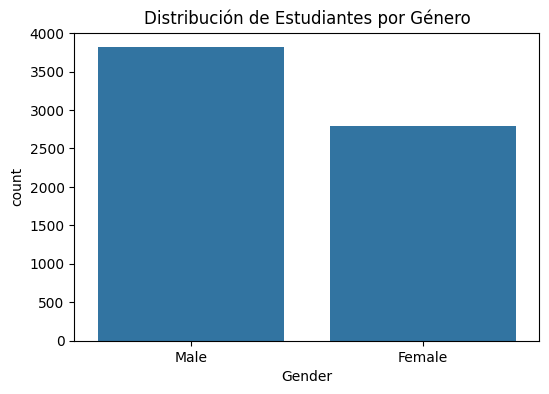

In [6]:
#Distribución de estudiantes por género
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Distribución de Estudiantes por Género")
plt.show()

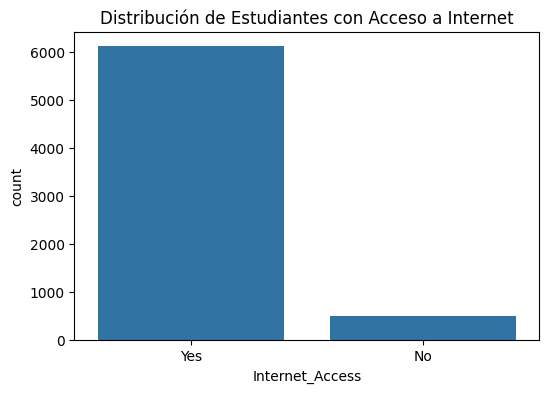

In [7]:
#Comparación entre Acceso a Internet
plt.figure(figsize=(6,4))
sns.countplot(x="Internet_Access", data=df)
plt.title("Distribución de Estudiantes con Acceso a Internet")
plt.show()

In [8]:
#Detectamos si existen valores nulos y en que columnas
valores_faltantes = df.isnull().sum()
print(valores_faltantes)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [9]:
#Primero: eliminamos los valores faltantes
df_ = df.dropna()
df_.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [10]:
#Verificamos el tamaño del df
len(df_)

6378

In [11]:
#Verificamos que ya no existan valores nulos
print(df_.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [12]:
#Eliminamos los valores duplicados
df_final = df_.drop_duplicates()
df_final.shape

(6378, 20)

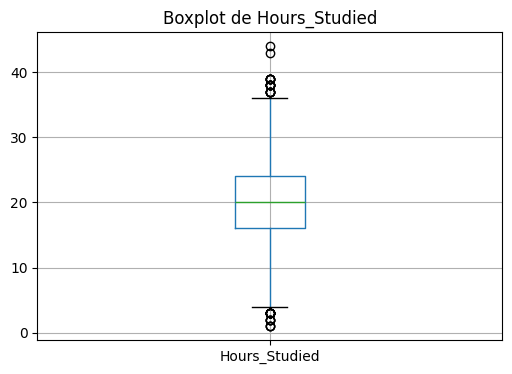

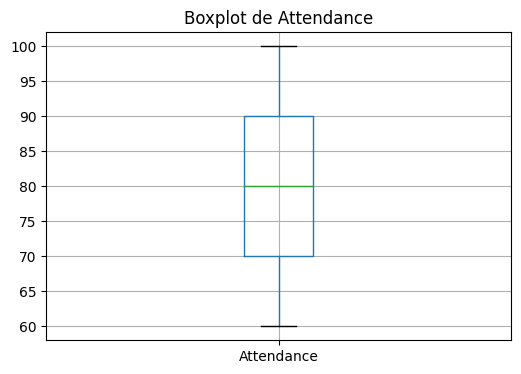

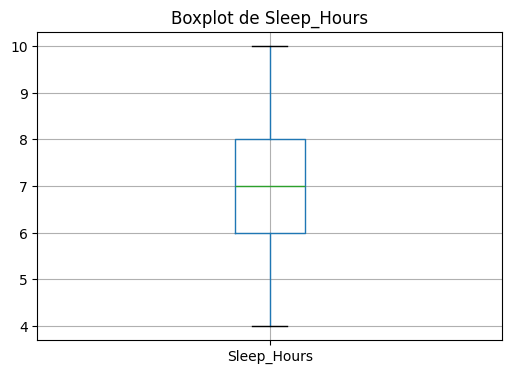

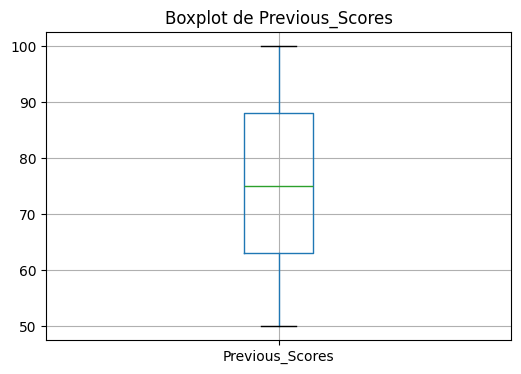

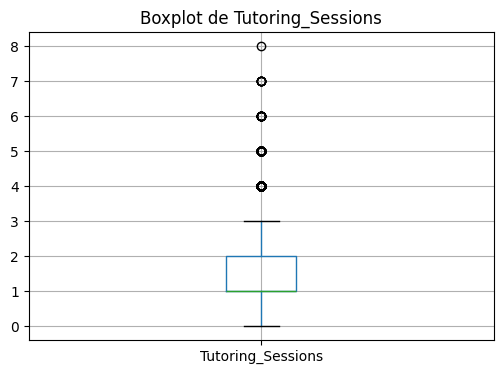

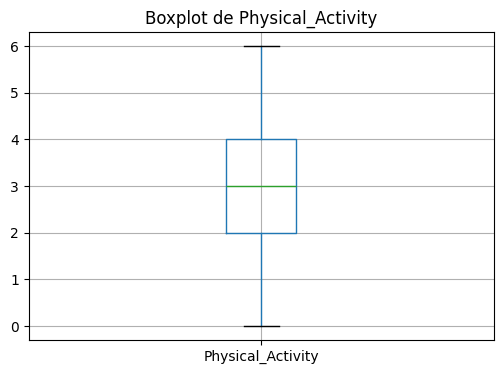

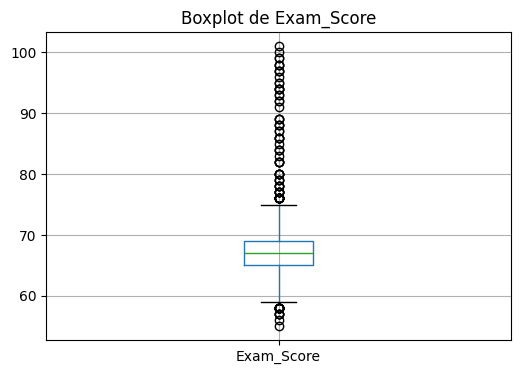

In [13]:
import matplotlib.pyplot as plt

columnas = df_final.select_dtypes(include='number').columns
for columna in columnas:

  plt.figure(figsize=(6,4))
  df_final.boxplot(column=columna)
  plt.title(f'Boxplot de {columna}')
  plt.show()

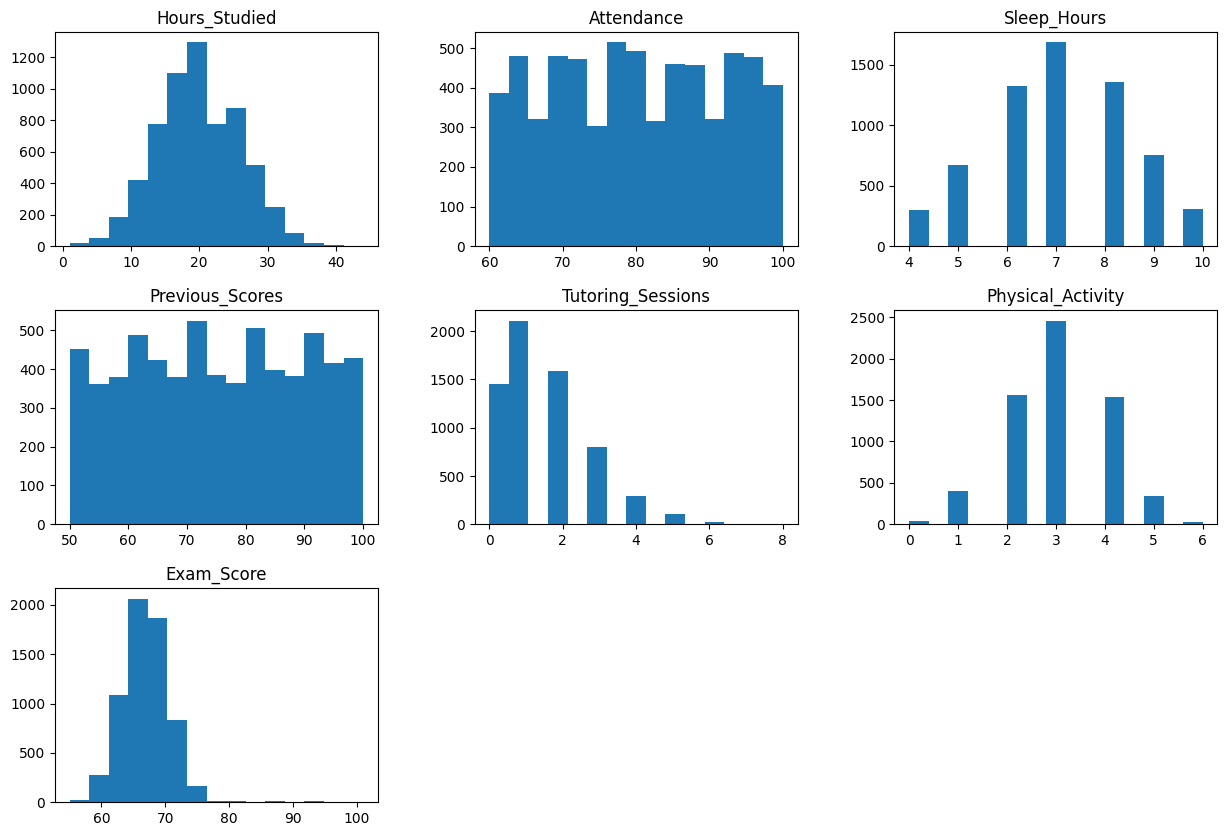

In [14]:
df_final.hist(bins=15, figsize=(15,10), grid=False)
plt.show()

In [15]:
df_final.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [16]:
#Separamos X e y
X = df_final.drop('Exam_Score', axis=1)  #elimina la columna porque es la variable objetivo
y = df_final['Exam_Score'] #coloca como etiqueta la columna


In [17]:
#Convierte las variables categoricas
X_ = pd.get_dummies(X, drop_first=True)
X_.shape

(6378, 27)

In [18]:
X_.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6378 non-null   int64
 1   Attendance                             6378 non-null   int64
 2   Sleep_Hours                            6378 non-null   int64
 3   Previous_Scores                        6378 non-null   int64
 4   Tutoring_Sessions                      6378 non-null   int64
 5   Physical_Activity                      6378 non-null   int64
 6   Parental_Involvement_Low               6378 non-null   bool 
 7   Parental_Involvement_Medium            6378 non-null   bool 
 8   Access_to_Resources_Low                6378 non-null   bool 
 9   Access_to_Resources_Medium             6378 non-null   bool 
 10  Extracurricular_Activities_Yes         6378 non-null   bool 
 11  Motivation_Level_Low               

In [19]:
#Dividimos nuestro dataset en train y split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
X_train.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
2356,18,95,7,96,2,4,True,False,False,False,...,False,False,False,True,True,True,False,True,False,True
4758,16,89,8,58,2,3,False,False,False,True,...,True,True,True,False,False,False,False,True,False,True
2281,16,69,6,55,1,1,False,True,False,False,...,False,True,False,False,False,True,False,True,False,True
485,11,65,7,78,2,3,False,True,False,False,...,True,True,True,False,False,False,True,False,True,False
4200,21,95,8,57,1,3,False,True,False,False,...,True,True,False,True,False,True,False,False,True,True


In [22]:
y_train.head()

,Exam_Score
2356,70
4758,67
2281,62
485,63
4200,69


In [23]:
from sklearn.ensemble import RandomForestRegressor

modelo_caracteristicas = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_caracteristicas.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [24]:
importancias = modelo_caracteristicas.feature_importances_

In [25]:
importancia_variables = pd.DataFrame({
    'Características': X_.columns,
    'Importancia': importancias
})

importancia_variables = importancia_variables.sort_values(by='Importancia', ascending=False)
importancia_variables

,Características,Importancia
1,Attendance,0.382529
0,Hours_Studied,0.244132
3,Previous_Scores,0.087748
4,Tutoring_Sessions,0.037831
2,Sleep_Hours,0.027002
5,Physical_Activity,0.026572
6,Parental_Involvement_Low,0.021636
8,Access_to_Resources_Low,0.018697
21,Learning_Disabilities_Yes,0.012329
9,Access_to_Resources_Medium,0.011344


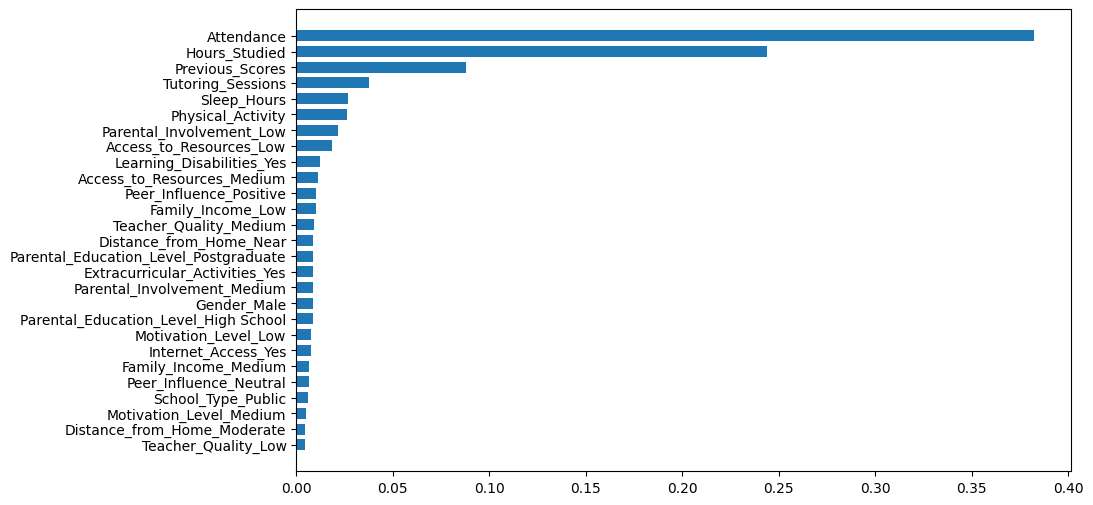

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importancia_variables['Características'], importancia_variables['Importancia'], height=0.7)
plt.gca().invert_yaxis()
plt.show()

In [54]:
top_variables = importancia_variables.sort_values(
    by="Importancia",
    ascending=False
)["Características"].head(10).tolist()
top_variables

['Attendance',
 'Hours_Studied',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Sleep_Hours',
 'Physical_Activity',
 'Parental_Involvement_Low',
 'Access_to_Resources_Low',
 'Learning_Disabilities_Yes',
 'Access_to_Resources_Medium']

In [55]:
X_train_selected = X_train[top_variables]
X_train_selected

,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Physical_Activity,Parental_Involvement_Low,Access_to_Resources_Low,Learning_Disabilities_Yes,Access_to_Resources_Medium
2356,95,18,96,2,7,4,True,False,True,False
4758,89,16,58,2,8,3,False,False,False,True
2281,69,16,55,1,6,1,False,False,False,False
485,65,11,78,2,7,3,False,False,False,False
4200,95,21,57,1,8,3,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
3904,70,30,84,2,6,3,False,True,False,False
5378,90,24,97,3,9,4,True,True,False,False
5415,65,24,52,1,7,1,True,False,False,False
5582,91,30,95,1,7,3,False,False,False,False


In [56]:
X_test_selected = X_test[top_variables]
X_test_selected

,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Physical_Activity,Parental_Involvement_Low,Access_to_Resources_Low,Learning_Disabilities_Yes,Access_to_Resources_Medium
2814,96,31,65,0,9,2,False,False,False,False
4421,84,13,94,3,9,2,False,False,True,True
4282,83,27,76,1,9,4,False,False,False,True
1246,97,20,94,1,7,1,False,False,False,True
4699,76,17,95,1,8,4,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
6220,76,27,55,3,9,0,False,False,False,False
5485,63,24,85,1,8,3,False,False,False,True
5076,81,20,61,0,6,4,True,False,True,True
6503,92,12,78,3,7,2,True,True,False,False


In [66]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=300,
                      random_state=42)

In [67]:
y_pred = rf_model.predict(X_test)

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest Regressor Metrics")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Random Forest Regressor Metrics
MAE  : 1.2598
MSE  : 5.9115
RMSE : 2.4314
R2   : 0.6196


In [73]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [74]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error


mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Metrics")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

Linear Regression Metrics
MAE  : 0.4873
MSE  : 4.1733
RMSE : 2.0429
R2   : 0.7314


In [57]:
print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))

0.7187813703799608
0.7314386522127074


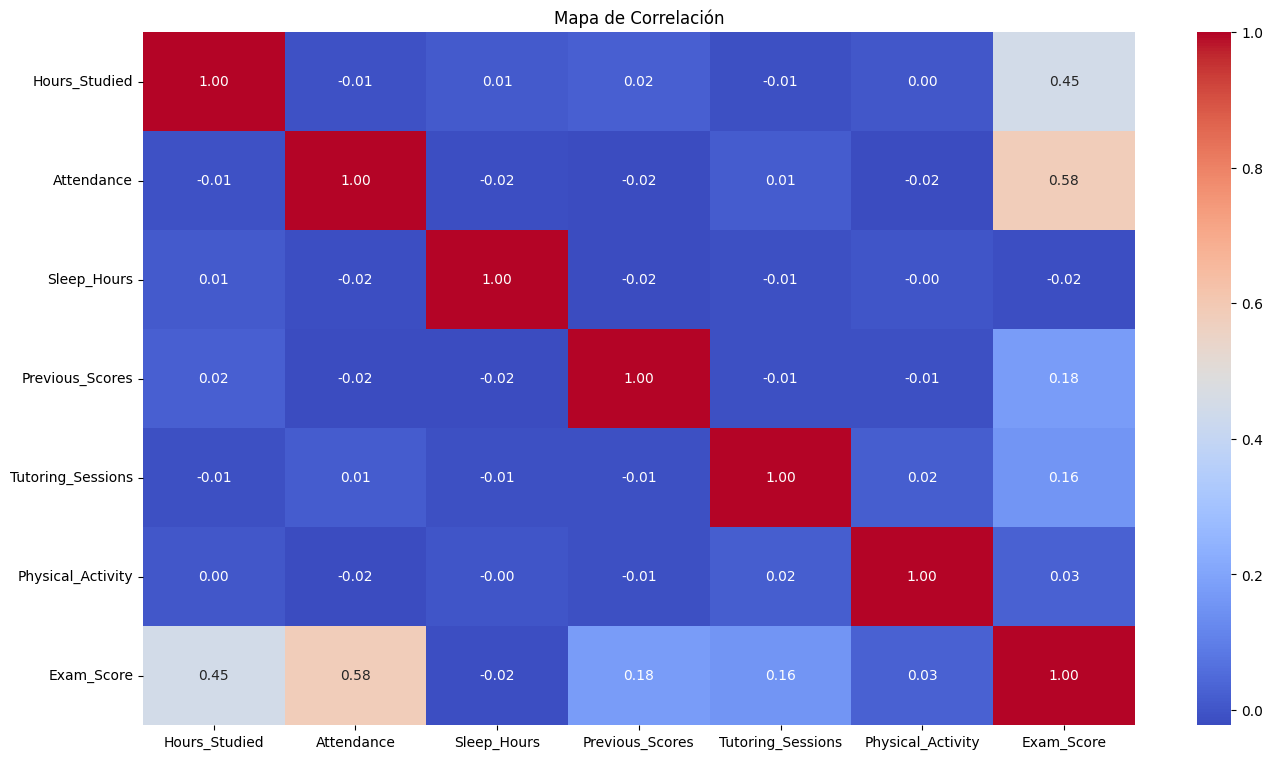

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

mapa_correlacion = df.select_dtypes(include="number")

if mapa_correlacion.shape[1] >= 4:
  plt.figure(figsize=(16,9))
  corr = mapa_correlacion.corr()
  sns.heatmap(
      corr,
      annot=True,
      cmap='coolwarm',
      fmt='.2f'
  )

  plt.title('Mapa de Correlación')
  plt.show()
else:
  print("No existen las suficientes columnas para grafica el mapa")

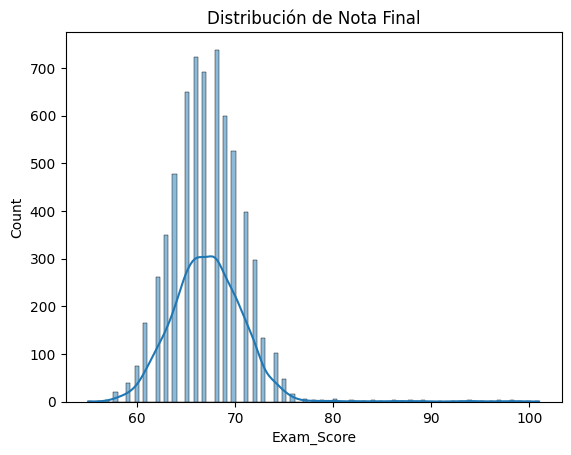

In [59]:
sns.histplot(df_final['Exam_Score'], kde=True)

plt.title('Distribución de Nota Final')
plt.show()

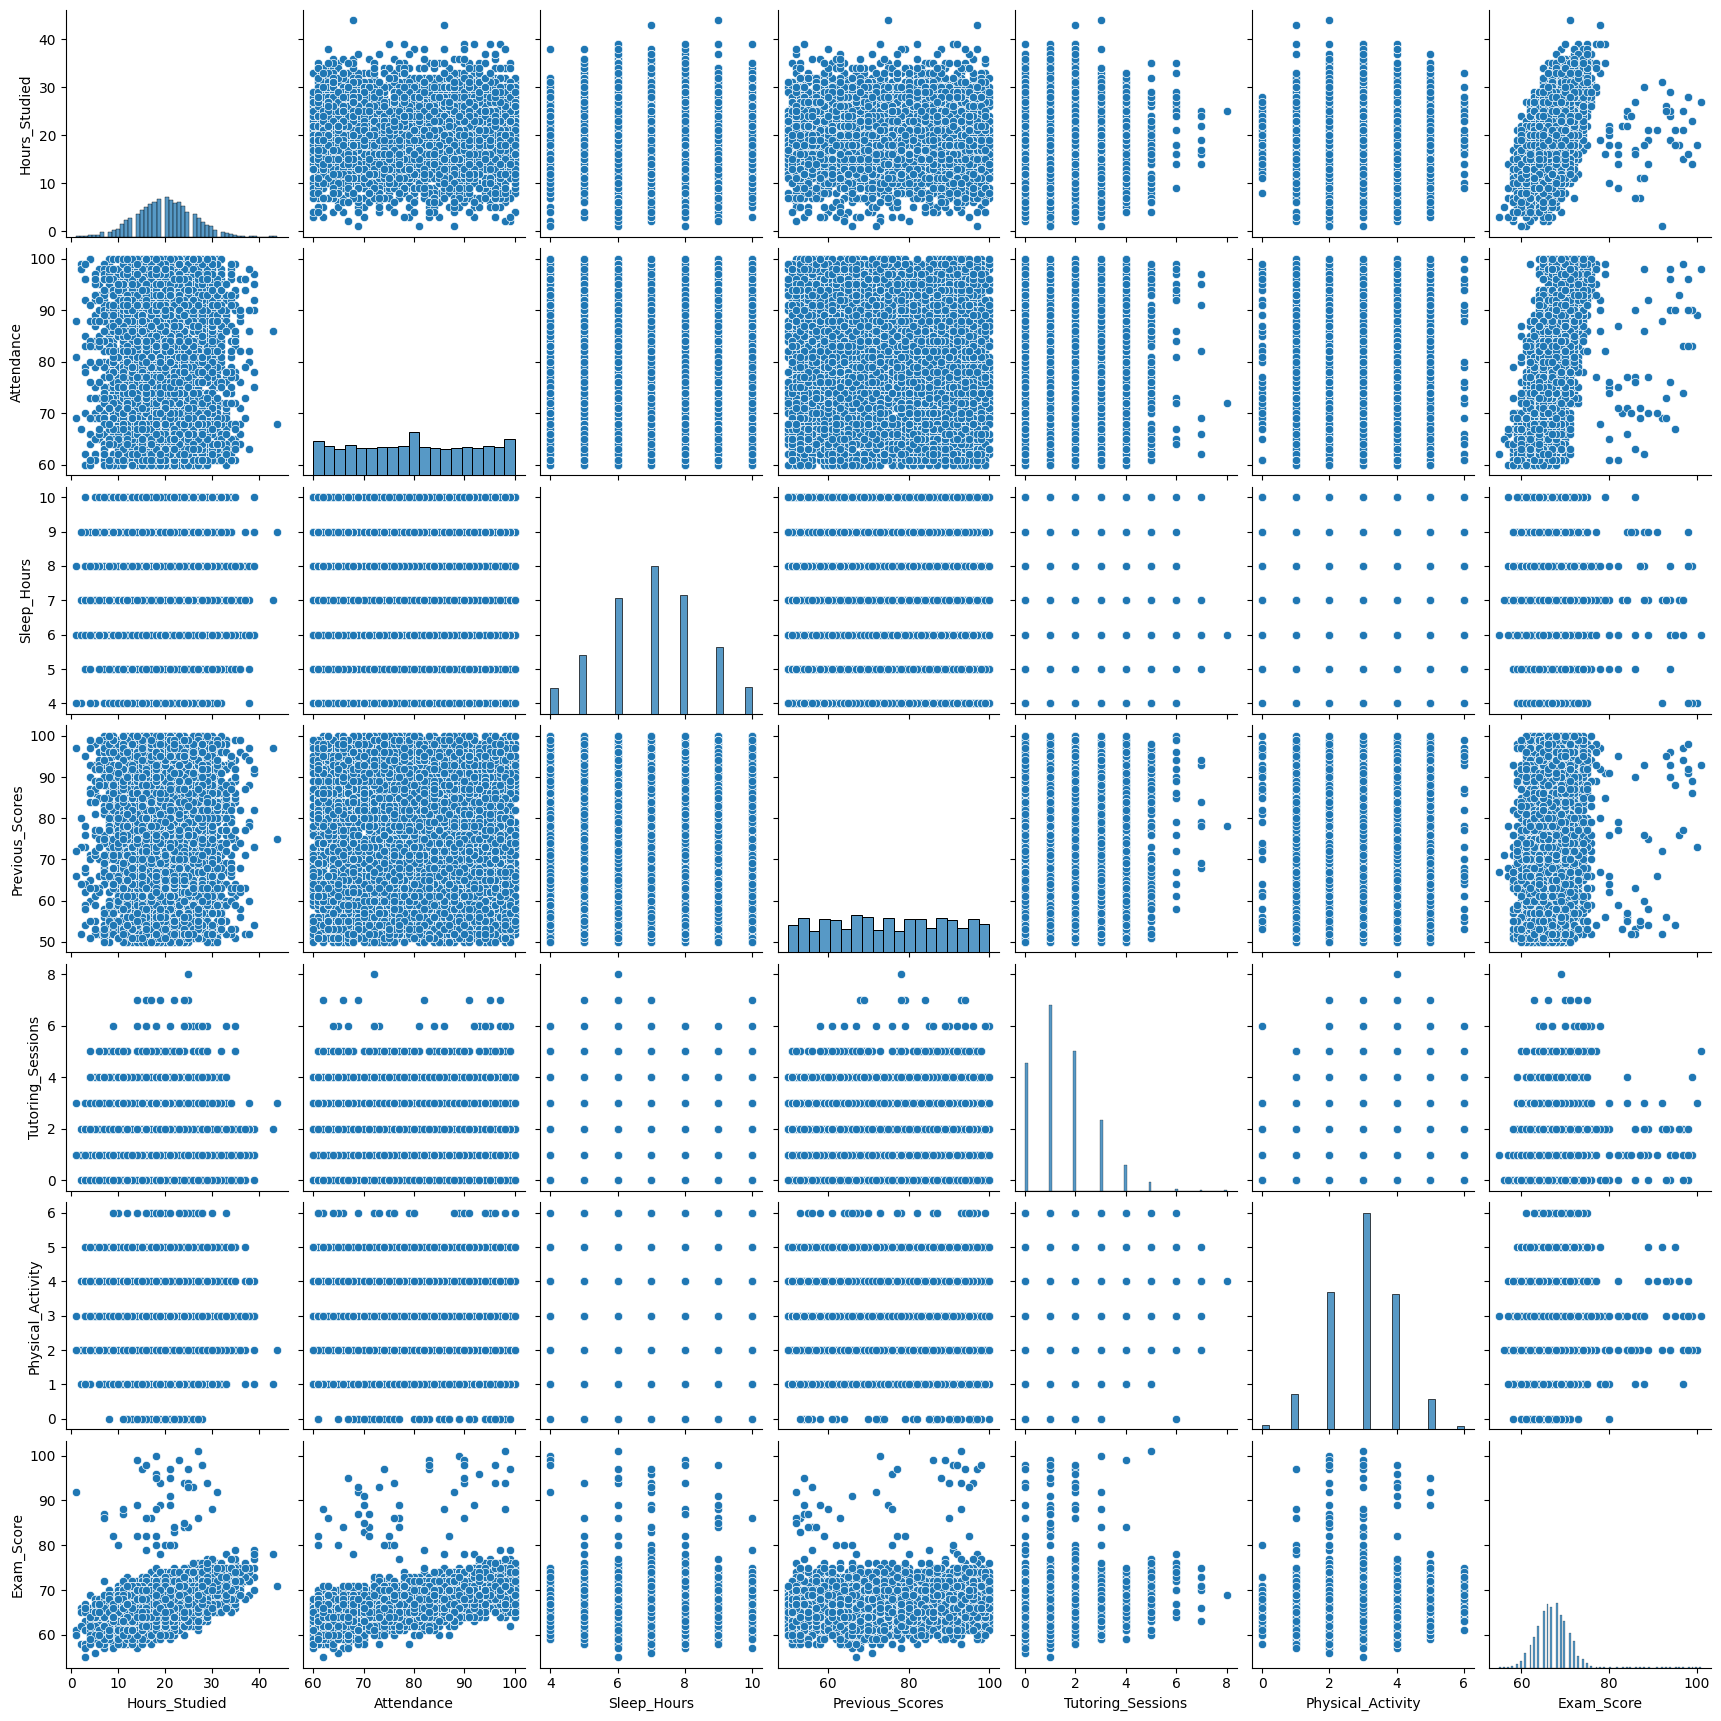

In [60]:
sns.pairplot(df_final)
plt.show()

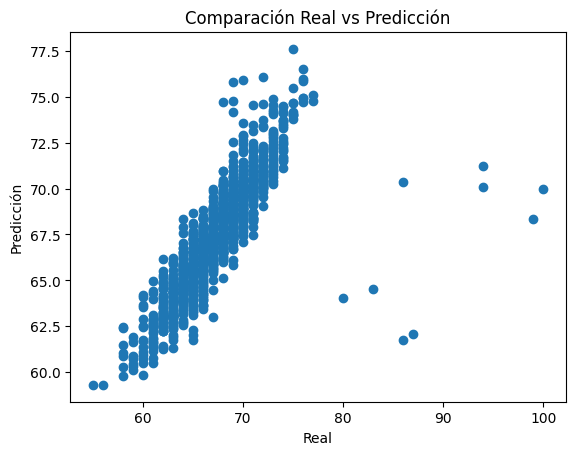

In [76]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Comparación Real vs Predicción")
plt.show()